In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [2]:
BASE_DIR = Path("../").resolve()
TRAIN_PATH = BASE_DIR / "data" / "cleaned" / "train.csv"
TEST_PATH = BASE_DIR / "data" / "cleaned" / "test.csv"
OUTPUT_DIR = BASE_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

X_train = train_df["text"]
y_train = train_df["label"]
X_test = test_df["text"]
y_test = test_df["label"]

print(train_df.shape, test_df.shape)
print(y_test.value_counts())

(941932, 2) (235483, 2)
label
Negative    125428
Neutral      61814
Positive     48241
Name: count, dtype: int64


train best model

In [6]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)

baseline metrics

In [7]:
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Macro F1:", baseline_macro_f1)

Baseline Accuracy: 0.8024188582615306
Baseline Macro F1: 0.7766973773862175


### confidence analysis table

This table is the basis of the simulation.
The lower the confidence, the more likely it is that the status is ambiguous and needs human review.

In [8]:
confidence = y_proba.max(axis=1)

results_df = test_df.copy()
results_df["predicted_label"] = y_pred
results_df["confidence"] = confidence
results_df["is_correct"] = results_df["label"] == results_df["predicted_label"]

results_df.head()

,text,label,predicted_label,confidence,is_correct
0,زلزلهم ياااا قساااام ارعبيهم مقاومتنا الشرسه ب...,Positive,Positive,0.998571,True
1,عارفه ايش قصه الناس الي بحكو الاوطان وبجمعو ال...,Negative,Negative,0.992341,True
2,الامن العام تعاملنا عدد مثيري الشغب منطقه الرا...,Neutral,Neutral,0.875725,True
3,اجبرهم عوضهم,Positive,Neutral,0.735927,False
4,لانريد ذلنا الوبدا القدسعاصمهفلسطينالابديه,Positive,Neutral,0.735927,False


sort by lowest confidence

In [9]:
results_sorted = results_df.sort_values("confidence", ascending=True).reset_index(drop=True)
results_sorted.head(10)

,text,label,predicted_label,confidence,is_correct
0,انا اتباع الرسول الاكرم محمد صلي الله عليه وسل...,Negative,Negative,0.334309,True
1,اللهم اكثر عزايهم عظم حزنهم احزانهم فرق شملهم ...,Negative,Negative,0.334915,True
2,موقف متميز للاشقاء المملكهالعربيهالسعوديه، وحت...,Positive,Negative,0.336125,False
3,نعم يمثلني,Negative,Negative,0.336853,True
4,مكدرتش اكطعه شاءالله المره الجاي برقعها,Neutral,Neutral,0.337117,True
5,نازيون يقدمون الدعم لاحتلال نازي صهيو لارض فلسطين,Negative,Negative,0.337265,True
6,محمد بعدما سمعت صوتك استسلمت,Neutral,Neutral,0.337776,True
7,ستر علي مسلم الدنيا ستره الله يوم القيامه,Neutral,Neutral,0.338059,True
8,نعم الرجل محمد محمد مبتدا موخر، خبر لمبتدا محذ...,Positive,Positive,0.338334,True
9,ولما برزوا لجالوت وجنوده قالوا ربنا افرغ علينا...,Positive,Positive,0.338786,True


### Simulation function

In [10]:
def simulate_human_review(df, review_fraction):
    df_sim = df.copy()

    n_review = int(len(df_sim) * review_fraction)

    review_idx = df_sim.index[:n_review]

    # نفترض أن الإنسان صحح هذه الحالات
    df_sim.loc[review_idx, "final_label"] = df_sim.loc[review_idx, "label"]
    df_sim.loc[review_idx, "final_is_correct"] = True

    # الباقي يظل كما هو
    remaining_idx = df_sim.index[n_review:]
    df_sim.loc[remaining_idx, "final_label"] = df_sim.loc[remaining_idx, "predicted_label"]
    df_sim.loc[remaining_idx, "final_is_correct"] = (
        df_sim.loc[remaining_idx, "label"] == df_sim.loc[remaining_idx, "predicted_label"]
    )

    acc = accuracy_score(df_sim["label"], df_sim["final_label"])
    macro_f1 = f1_score(df_sim["label"], df_sim["final_label"], average="macro")

    return {
        "review_fraction": review_fraction,
        "reviewed_samples": n_review,
        "accuracy": acc,
        "macro_f1": macro_f1
    }

run the simulation

In [11]:
review_levels = [0.00, 0.05, 0.10, 0.15, 0.20]

simulation_results = [simulate_human_review(results_sorted, frac) for frac in review_levels]
simulation_df = pd.DataFrame(simulation_results)

simulation_df

,review_fraction,reviewed_samples,accuracy,macro_f1
0,0.00,0,0.802419,0.776697
1,0.05,11774,0.830056,0.809435
2,0.10,23548,0.853905,0.836360
3,0.15,35322,0.875698,0.860810
4,0.20,47096,0.895423,0.882795


save results

In [12]:
simulation_df.to_csv(OUTPUT_DIR / "human_in_the_loop_simulation.csv", index=False)
simulation_df

,review_fraction,reviewed_samples,accuracy,macro_f1
0,0.00,0,0.802419,0.776697
1,0.05,11774,0.830056,0.809435
2,0.10,23548,0.853905,0.836360
3,0.15,35322,0.875698,0.860810
4,0.20,47096,0.895423,0.882795


plot improvement

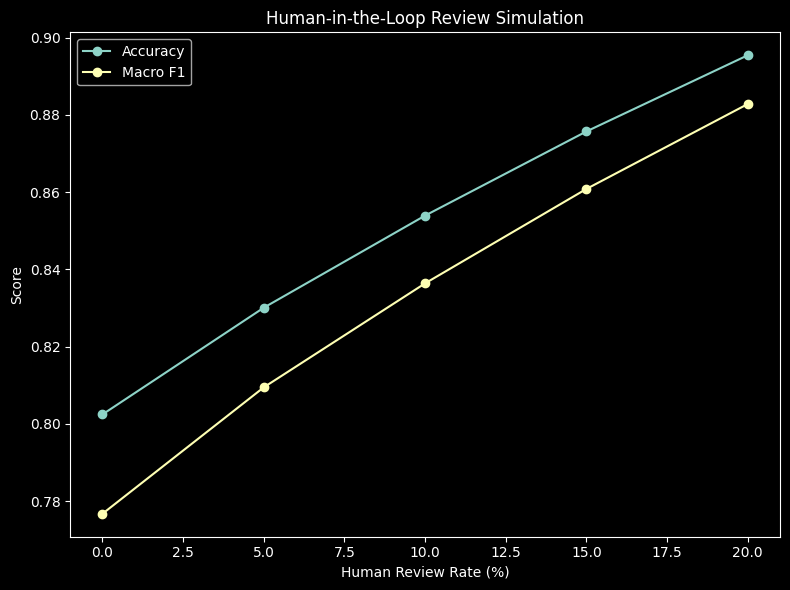

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(simulation_df["review_fraction"] * 100, simulation_df["accuracy"], marker="o", label="Accuracy")
plt.plot(simulation_df["review_fraction"] * 100, simulation_df["macro_f1"], marker="o", label="Macro F1")
plt.xlabel("Human Review Rate (%)")
plt.ylabel("Score")
plt.title("Human-in-the-Loop Review Simulation")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "human_in_the_loop_simulation.png", dpi=200)
plt.show()

 inspect reviewed uncertain cases

In [14]:
lowest_conf_examples = results_sorted.head(20)[["text", "label", "predicted_label", "confidence", "is_correct"]]
lowest_conf_examples.to_csv(OUTPUT_DIR / "lowest_confidence_examples.csv", index=False)
lowest_conf_examples

,text,label,predicted_label,confidence,is_correct
0,انا اتباع الرسول الاكرم محمد صلي الله عليه وسل...,Negative,Negative,0.334309,True
1,اللهم اكثر عزايهم عظم حزنهم احزانهم فرق شملهم ...,Negative,Negative,0.334915,True
2,موقف متميز للاشقاء المملكهالعربيهالسعوديه، وحت...,Positive,Negative,0.336125,False
3,نعم يمثلني,Negative,Negative,0.336853,True
4,مكدرتش اكطعه شاءالله المره الجاي برقعها,Neutral,Neutral,0.337117,True
5,نازيون يقدمون الدعم لاحتلال نازي صهيو لارض فلسطين,Negative,Negative,0.337265,True
6,محمد بعدما سمعت صوتك استسلمت,Neutral,Neutral,0.337776,True
7,ستر علي مسلم الدنيا ستره الله يوم القيامه,Neutral,Neutral,0.338059,True
8,نعم الرجل محمد محمد مبتدا موخر، خبر لمبتدا محذ...,Positive,Positive,0.338334,True
9,ولما برزوا لجالوت وجنوده قالوا ربنا افرغ علينا...,Positive,Positive,0.338786,True
